### 라이브러리 설치

In [ ]:
!pip install numpy===1.23.5
!pip install mxnet==1.9.1

### 이미지 불러오기

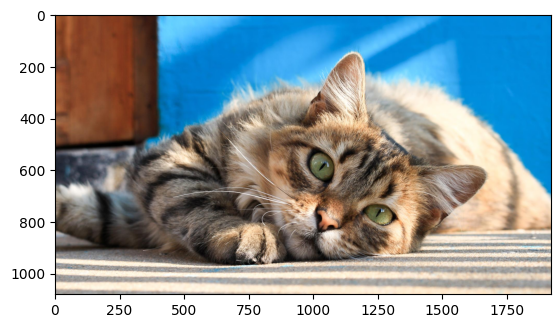

In [ ]:
import matplotlib.pyplot as plt
import mxnet as mx
from mxnet.gluon.data.vision import transforms

example_image = mx.image.imread("/content/cat.jpg")
plt.imshow(example_image.asnumpy())

### RandomResizedCrop 적용 위한 함수 생성

In [ ]:
def show_images(imgs, num_rows, num_cols, scale=2):
  aspect_ratio = imgs[0].shape[0]/imgs[0].shape[1] # 확장할 이미지의 크기 조정
  figsize = (num_cols * scale, num_rows * scale * aspect_ratio)
  _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

  for i in range(num_rows):
    for j in range(num_cols):
      axes[i][j].imshow(imgs[i * num_cols+j].asnumpy())
      axes[i][j].axes.get_xaxis().set_visible(False) # x축 전체를 숨김
      axes[i][j].axes.get_yaxis().set_visible(False) # y축 전체를 숨김
  plt.subplots_adjust(hspace=0.1, wspace=0)
  return axes

def apply(img,aug,num_rows=2,num_cols=4,scale=3):
  Y = [aug(img) for _ in range(num_rows * num_cols)] # 다양한 샘플을 얻기 위해 여러 번 데이터 확장 적용
  show_images(Y,num_rows, num_cols, scale)

### RandomResizedCrop이 적용된 이미지 출력

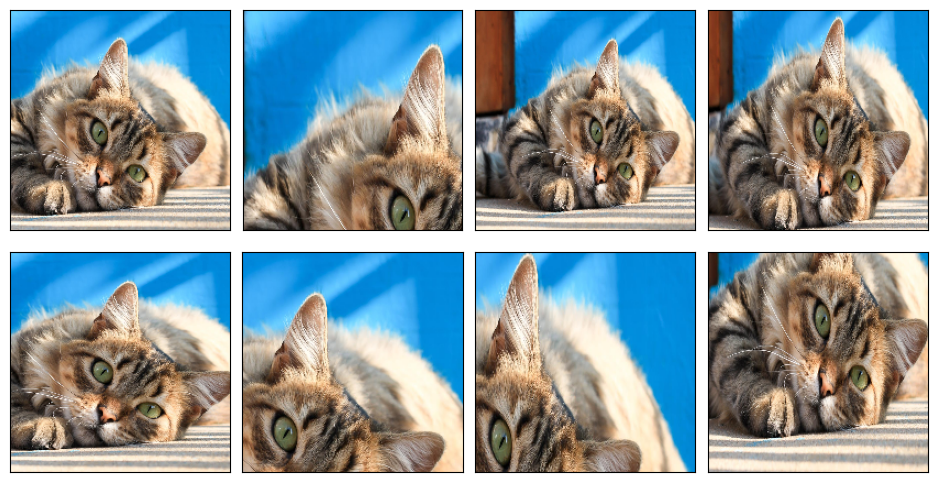

In [ ]:
# ratio를 통해서 너비와 비율을 조절한 후 scale을 통해 자르고, 최종적으로 출력할 size로 조정

shape_aug = transforms.RandomResizedCrop(size=(200,200), # 출력할 크기를 200 X 200으로 조정
                                         scale=(0.1,1), # 면적 비율을 0.1~1(10~100%) 범위 내에서 무작위로 자름
                                         ratio=(0.5, 2)) # 면적의 너비와 높이 비율을 0.5~2 범위 내에서 무작위로 조절

# RandomResizedCrop이 적용된 이미지를 출력
apply(example_image, shape_aug)